In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import os
import pandas as pd
import numpy as np
import bioframe as bf
from ggner_3d import plotting
plotting.update_rcparams()

### boundaries +- 20kb

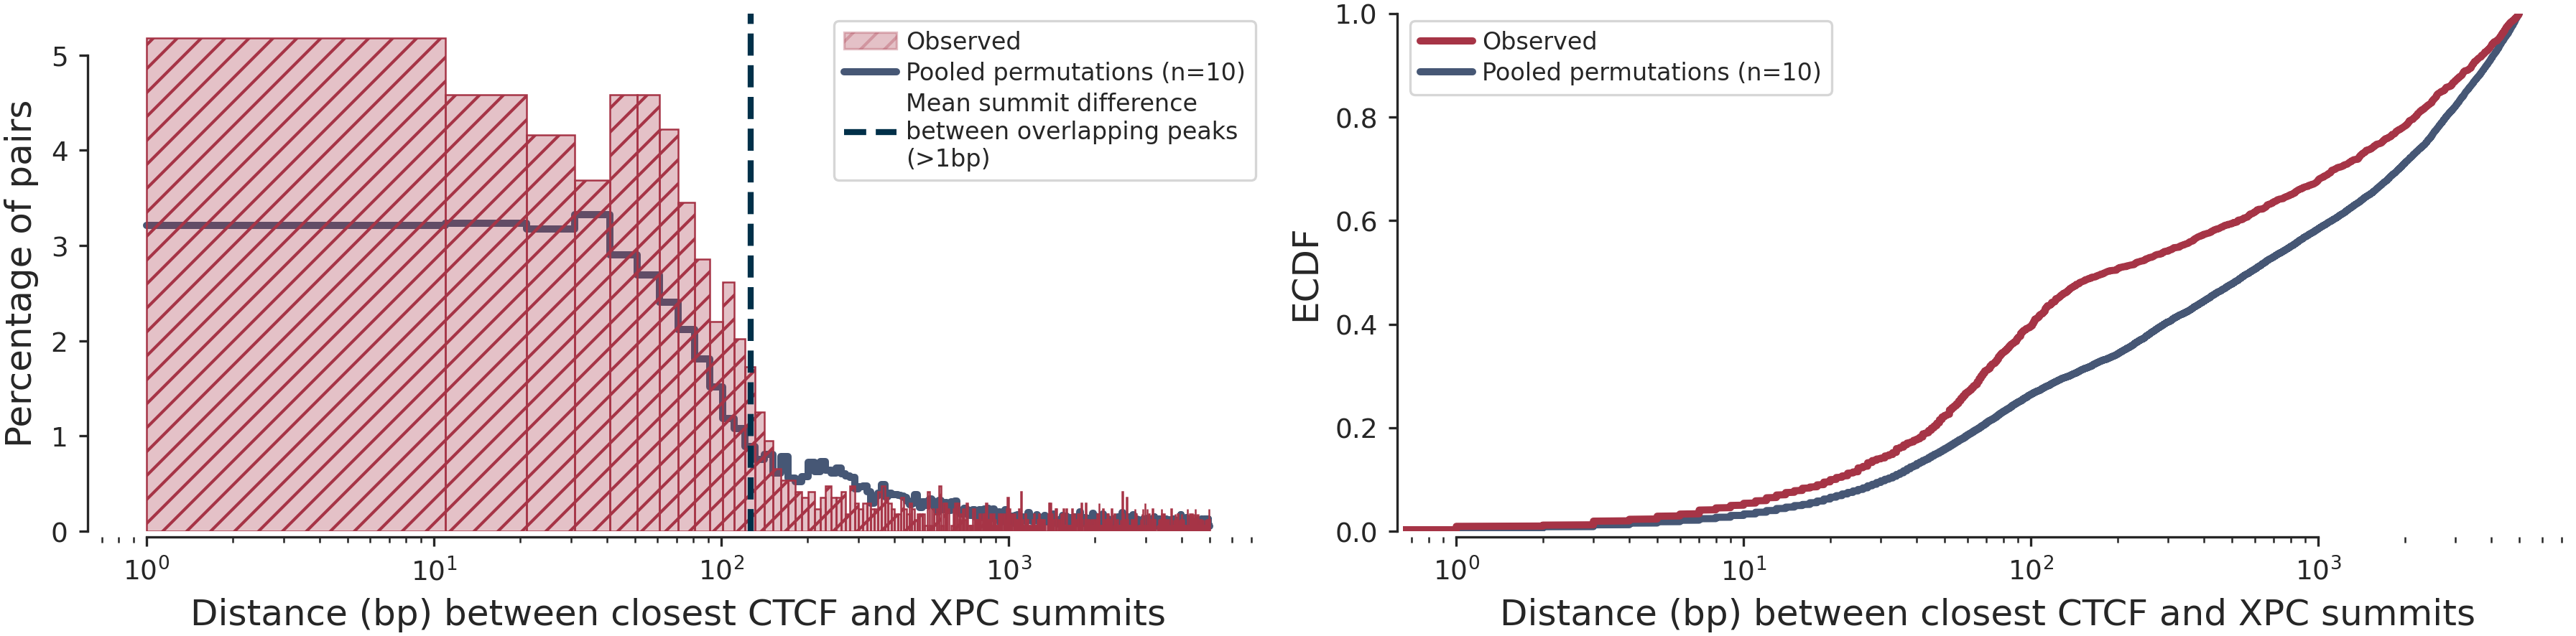

In [2]:
# -----------------------------
# Inputs
# -----------------------------
perm_dir = "/home/carlos/Clone/xpc_ctcf_peaks/boundaries_20kb_flank/03_perm/saved_perm_dists"
observed_path = "/home/carlos/Clone/xpc_ctcf_peaks/boundaries_20kb_flank/02_obs/observed_distances.txt"
mean_abs_summit_diff = pd.read_csv('/home/carlos/Clone/xpc_ctcf_peaks/boundaries_20kb_flank/02_obs/XPC_CTCF.overlap_peak_summit_distances.summary.tsv', sep='\t').iloc[1,1]

out_png = "/home/carlos/Clone/ggner-3d/figs/fig4/ctcf_xpc_distance_distribution_boundaries.png"
out_svg = "/home/carlos/Clone/ggner-3d/figs/fig4/ctcf_xpc_distance_distribution_boundaries.svg"

# -----------------------------
# Load permutation distances
# -----------------------------
perm_paths = sorted(os.listdir(perm_dir))
perm_dists = []

for idx, fname in enumerate(perm_paths):
    df = pd.read_csv(os.path.join(perm_dir, fname), header=None)
    df.columns = ["distance"]
    df.insert(0, "perm_id", idx)
    perm_dists.append(df)

perm_df = pd.concat(perm_dists, ignore_index=True)

# Pool all permutations into one distribution for visualization
perm_df_pooled = perm_df.copy()
perm_df_pooled["perm_id"] = "permutations"

# -----------------------------
# Load observed distances
# -----------------------------
observed_data = pd.read_csv(observed_path, header=None)
observed_data.columns = ["distance"]
observed_data.insert(0, "perm_id", "observed")

# -----------------------------
# Merge + preprocess
# -----------------------------
merged_df = pd.concat([perm_df_pooled, observed_data], ignore_index=True)

# avoid log(0)
merged_df["distance"] = merged_df["distance"] + 1

# optional tail trim
merged_df = merged_df[merged_df["distance"] < 5_000].copy()

# ensure stable hue order
merged_df["perm_id"] = pd.Categorical(
    merged_df["perm_id"],
    categories=["observed", "permutations"],
    ordered=True
)


# Make sure both are trimmed consistently (if not already)
perm = perm_df_pooled.copy()
obs  = observed_data.copy()

perm = perm[perm["distance"] < 5000].copy()
obs  = obs[obs["distance"] < 5000].copy()

# consistent binning
bins = 500
binrange = (1, 5000)

fig, ax = plt.subplots(ncols=2, figsize=(12, 3), constrained_layout=True)

# =============================
# ax[0] Histogram
# =============================

# Observed: filled + hatch, same color
n_before = len(ax[0].patches)
sns.histplot(
    data=obs,
    x="distance",
    stat="percent",
    bins=bins,
    binrange=binrange,
    element="bars",
    fill=True,
    alpha=0.30,
    color=plotting.COLORS[1],
    edgecolor=plotting.COLORS[1],   # hatch uses edgecolor
    linewidth=0.6,
    ax=ax[0],
    zorder=2,
)

# Permutations: outline (step), same color
sns.histplot(
    data=perm,
    x="distance",
    stat="percent",
    bins=bins,
    binrange=binrange,
    element="step",
    fill=False,
    linewidth=2.4,
    color=plotting.COLORS[0],
    ax=ax[0],
    zorder=1,
)

# Apply hatch only to the newly-added observed bars
for p in ax[0].patches[n_before:]:
    p.set_hatch("///")   # try "//", "xx", ".." as alternatives

ax[0].set_xscale("log")
ax[0].set_ylabel("Percentage of pairs")
ax[0].set_xlabel("Distance (bp) between closest CTCF and XPC summits")

mean_line0 = ax[0].axvline(
    mean_abs_summit_diff,
    color="#003049",
    linestyle="--",
    linewidth=2,
    label="Mean summit difference\nbetween overlapping peaks\n(>1bp)",
)

# Legend with proxy artists so the styles match exactly
legend_handles0 = [
    Patch(facecolor=plotting.COLORS[1], edgecolor=plotting.COLORS[1], hatch="///", alpha=0.30, label="Observed"),
    Line2D([0], [0], color=plotting.COLORS[0], lw=2.4, label="Pooled permutations (n=10)"),
    mean_line0,
]
ax[0].legend(handles=legend_handles0, title="")

# =============================
# ax[1] ECDF
# =============================

def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, x.size + 1) / x.size
    return x, y

x_perm, y_perm = ecdf(perm["distance"].values)
x_obs,  y_obs  = ecdf(obs["distance"].values)

# Permutations ECDF (solid)
ax[1].plot(x_perm, y_perm, color=plotting.COLORS[0], linewidth=2.4, label="Pooled permutations (n=10)")

# Observed ECDF (different linestyle, same color)
ax[1].plot(x_obs, y_obs, color=plotting.COLORS[1], linewidth=2.4, linestyle="-", label="Observed")

ax[1].set_xscale("log")
ax[1].set_ylim(0, 1)
ax[1].set_ylabel("ECDF")
ax[1].set_xlabel("Distance (bp) between closest CTCF and XPC summits")

# ECDF legend
ax[1].legend(title="")
# flip the order of legend entries to match the histogram
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles[::-1], labels[::-1], title="")

plotting.despine(ax[0])
plotting.despine(ax[1])

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_svg, bbox_inches="tight")

### genomewide

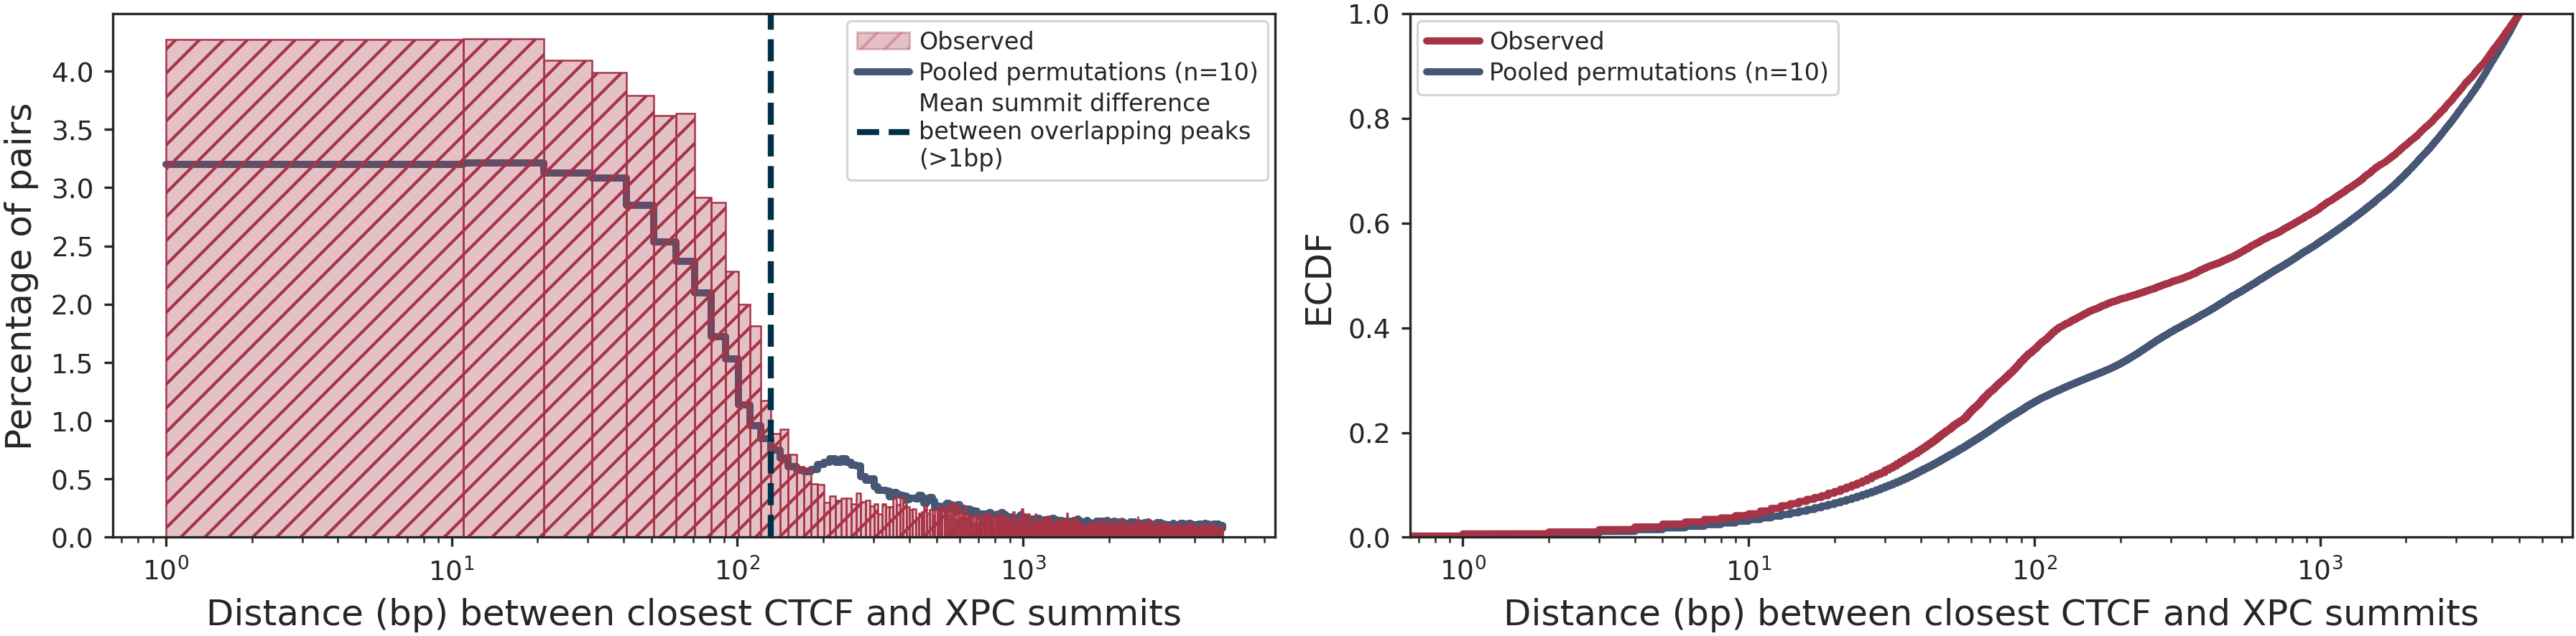

In [3]:
# -----------------------------
# Inputs
# -----------------------------
perm_dir = "/home/carlos/Clone/xpc_ctcf_peaks/genomewide/03_perm/saved_perm_dists"
observed_path = "/home/carlos/Clone/xpc_ctcf_peaks/genomewide/02_obs/observed_distances.txt"
mean_abs_summit_diff = pd.read_csv('/home/carlos/Clone/xpc_ctcf_peaks/genomewide/02_obs/XPC_CTCF.overlap_peak_summit_distances.summary.tsv', sep='\t').iloc[1,1]

out_png = "/home/carlos/Clone/ggner-3d/figs/fig4/ctcf_xpc_distance_distribution_genomewide.png"
out_svg = "/home/carlos/Clone/ggner-3d/figs/fig4/ctcf_xpc_distance_distribution_genomewide.svg"

# -----------------------------
# Load permutation distances
# -----------------------------
perm_paths = sorted(os.listdir(perm_dir))
perm_dists = []

for idx, fname in enumerate(perm_paths):
    df = pd.read_csv(os.path.join(perm_dir, fname), header=None)
    df.columns = ["distance"]
    df.insert(0, "perm_id", idx)
    perm_dists.append(df)

perm_df = pd.concat(perm_dists, ignore_index=True)

# Pool all permutations into one distribution for visualization
perm_df_pooled = perm_df.copy()
perm_df_pooled["perm_id"] = "permutations"

# -----------------------------
# Load observed distances
# -----------------------------
observed_data = pd.read_csv(observed_path, header=None)
observed_data.columns = ["distance"]
observed_data.insert(0, "perm_id", "observed")

# -----------------------------
# Merge + preprocess
# -----------------------------
merged_df = pd.concat([perm_df_pooled, observed_data], ignore_index=True)

# avoid log(0)
merged_df["distance"] = merged_df["distance"] + 1

# optional tail trim
merged_df = merged_df[merged_df["distance"] < 5_000].copy()

# ensure stable hue order
merged_df["perm_id"] = pd.Categorical(
    merged_df["perm_id"],
    categories=["observed", "permutations"],
    ordered=True
)


# Make sure both are trimmed consistently (if not already)
perm = perm_df_pooled.copy()
obs  = observed_data.copy()

perm = perm[perm["distance"] < 5000].copy()
obs  = obs[obs["distance"] < 5000].copy()

# consistent binning
bins = 500
binrange = (1, 5000)

fig, ax = plt.subplots(ncols=2, figsize=(12, 3), constrained_layout=True)

# =============================
# ax[0] Histogram
# =============================

# Observed: filled + hatch, same color
n_before = len(ax[0].patches)
sns.histplot(
    data=obs,
    x="distance",
    stat="percent",
    bins=bins,
    binrange=binrange,
    element="bars",
    fill=True,
    alpha=0.30,
    color=plotting.COLORS[1],
    edgecolor=plotting.COLORS[1],   # hatch uses edgecolor
    linewidth=0.6,
    ax=ax[0],
    zorder=2,
)

# Permutations: outline (step), same color
sns.histplot(
    data=perm,
    x="distance",
    stat="percent",
    bins=bins,
    binrange=binrange,
    element="step",
    fill=False,
    linewidth=2.4,
    color=plotting.COLORS[0],
    ax=ax[0],
    zorder=1,
)

# Apply hatch only to the newly-added observed bars
for p in ax[0].patches[n_before:]:
    p.set_hatch("///")   # try "//", "xx", ".." as alternatives

ax[0].set_xscale("log")
ax[0].set_ylabel("Percentage of pairs")
ax[0].set_xlabel("Distance (bp) between closest CTCF and XPC summits")

mean_line0 = ax[0].axvline(
    mean_abs_summit_diff,
    color="#003049",
    linestyle="--",
    linewidth=2,
    label="Mean summit difference\nbetween overlapping peaks\n(>1bp)",
)

# Legend with proxy artists so the styles match exactly
legend_handles0 = [
    Patch(facecolor=plotting.COLORS[1], edgecolor=plotting.COLORS[1], hatch="///", alpha=0.30, label="Observed"),
    Line2D([0], [0], color=plotting.COLORS[0], lw=2.4, label="Pooled permutations (n=10)"),
    mean_line0,
]
ax[0].legend(handles=legend_handles0, title="")

# =============================
# ax[1] ECDF
# =============================

def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, x.size + 1) / x.size
    return x, y

x_perm, y_perm = ecdf(perm["distance"].values)
x_obs,  y_obs  = ecdf(obs["distance"].values)

# Permutations ECDF (solid)
ax[1].plot(x_perm, y_perm, color=plotting.COLORS[0], linewidth=2.4, label="Pooled permutations (n=10)")

# Observed ECDF (different linestyle, same color)
ax[1].plot(x_obs, y_obs, color=plotting.COLORS[1], linewidth=2.4, linestyle="-", label="Observed")

ax[1].set_xscale("log")
ax[1].set_ylim(0, 1)
ax[1].set_ylabel("ECDF")
ax[1].set_xlabel("Distance (bp) between closest CTCF and XPC summits")

# ECDF legend
ax[1].legend(title="")
# flip the order of legend entries to match the histogram
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles[::-1], labels[::-1], title="")

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_svg, bbox_inches="tight")

### active promoters xpc peaks ~ promoter marks

In [4]:
tss_bed = pd.read_csv('/home/carlos/Clone/ggner-3d/tss.bed', sep='\t', header=None)
tss_bed.columns = ['chrom', 'start', 'end', 'gene_id', 'score', 'strand']

whitelist = [f'chr{i}' for i in range(1, 23)] + ['chrX']

tss_bed = tss_bed[tss_bed['chrom'].isin(whitelist)].copy()
chrom_sizes = pd.read_csv('/home/carlos/Clone/xpc_ctcf_peaks/hg38.chrom.sizes', sep='\t', header=None)
chrom_sizes_dict = pd.Series(chrom_sizes[1].values, index=chrom_sizes[0].values).to_dict()

import pandas as pd
import numpy as np
from typing import Mapping, Union

def promoters_from_tss_bed(
    tss_bed: pd.DataFrame,
    chrom_sizes: Union[Mapping[str, int], pd.Series, pd.DataFrame],
    upstream: int = 1000,
    downstream: int = 100,
    drop_zero_len: bool = True,
) -> pd.DataFrame:
    """
    Expand 1bp TSS BED intervals to strand-aware promoter windows and clamp to chromosome bounds.

    Expected input BED (0-based, half-open):
      columns: ['chrom','start','end','gene_id','score','strand']
      where TSS is typically [tss-1, tss) and end = start+1.

    Strand-aware expansion (bedtools slop -s equivalent):
      '+' : start -= upstream, end += downstream
      '-' : start -= downstream, end += upstream

    chrom_sizes:
      - dict-like {chrom: length}
      - pandas Series with index=chrom, values=length
      - DataFrame with columns ['chrom','length'] or ['chrom','size']

    Returns a new DataFrame with updated start/end (int), same columns.
    """
    required = ['chrom', 'start', 'end', 'gene_id', 'score', 'strand']
    missing = [c for c in required if c not in tss_bed.columns]
    if missing:
        raise ValueError(f"tss_bed is missing columns: {missing}")

    # Build chrom->length mapping
    if isinstance(chrom_sizes, pd.DataFrame):
        if 'chrom' not in chrom_sizes.columns:
            raise ValueError("chrom_sizes DataFrame must contain a 'chrom' column.")
        len_col = 'length' if 'length' in chrom_sizes.columns else ('size' if 'size' in chrom_sizes.columns else None)
        if len_col is None:
            raise ValueError("chrom_sizes DataFrame must contain a 'length' or 'size' column.")
        sizes = pd.Series(chrom_sizes[len_col].values, index=chrom_sizes['chrom'].values).to_dict()
    elif isinstance(chrom_sizes, pd.Series):
        sizes = chrom_sizes.to_dict()
    else:
        sizes = dict(chrom_sizes)

    df = tss_bed.copy()

    # Ensure integer coordinates
    df['start'] = pd.to_numeric(df['start'], errors='raise').astype(np.int64)
    df['end']   = pd.to_numeric(df['end'], errors='raise').astype(np.int64)

    # Map chromosome lengths; error if any missing
    df['_chr_len'] = df['chrom'].map(sizes)
    if df['_chr_len'].isna().any():
        missing_chroms = sorted(df.loc[df['_chr_len'].isna(), 'chrom'].unique().tolist())
        raise KeyError(f"Missing chromosome sizes for: {missing_chroms}")

    # Strand-aware "slop": swap left/right on '-' strand
    is_plus = df['strand'].astype(str).eq('+').to_numpy()
    left  = np.where(is_plus, upstream, downstream).astype(np.int64)
    right = np.where(is_plus, downstream, upstream).astype(np.int64)

    new_start = df['start'].to_numpy(np.int64) - left
    new_end   = df['end'].to_numpy(np.int64) + right

    # Clamp to [0, chr_len]
    chr_len = df['_chr_len'].to_numpy(np.int64)
    new_start = np.maximum(new_start, 0)
    new_end   = np.minimum(new_end, chr_len)

    df['start'] = new_start
    df['end']   = new_end

    if drop_zero_len:
        df = df[df['end'] > df['start']].copy()

    return df.drop(columns=['_chr_len'])

promoters = promoters_from_tss_bed(tss_bed, chrom_sizes_dict, upstream=2000, downstream=200)
promoters

,chrom,start,end,gene_id,score,strand
0,chr20,47992087,47994288,ENSG00000237423.4,.,-
1,chr20,24992581,24994782,ENSG00000101474.13,.,-
2,chr19,35584160,35586361,ENSG00000283758.2,.,+
3,chr17,51120725,51122926,ENSG00000008294.23,.,-
4,chr17,20321057,20323258,ENSG00000266839.3,.,+
...,...,...,...,...,...,...
78894,chr5,97057157,97059358,ENSG00000213701.4,.,-
78895,chr4,47650668,47652869,ENSG00000277388.1,.,+
78896,chr3,49160650,49162851,ENSG00000270441.1,.,-
78897,chr1,208999337,209001538,ENSG00000278684.1,.,+


In [5]:
flank = 10_000

narrow_cols = [
    "chrom","start","end","name","score","strand",
    "signalValue","pValue","qValue","peak"  # peak == summit offset from start
]

xpc_peaks = pd.read_csv(
    "/home/carlos/Clone/xpc_ctcf_peaks/XPC_all.narrowPeak",
    sep="\t", header=None, names=narrow_cols, usecols=range(10)
)
ctcf_peaks = pd.read_csv(
    "/home/carlos/Clone/xpc_ctcf_peaks/CTCF_all.narrowPeak",
    sep="\t", header=None, names=narrow_cols, usecols=[0,1,2]
).rename(columns={"name": "chrom"})  # (since we only read 0,1,2 we’ll rename below)
ctcf_peaks.columns = ["chrom","start","end"]

# ints
xpc_peaks[["start","end","peak"]] = xpc_peaks[["start","end","peak"]].astype(int)
ctcf_peaks[["start","end"]] = ctcf_peaks[["start","end"]].astype(int)

# promoters: ensure 1-bp intervals (BED end must be > start)
promoters_1bp = promoters[["chrom","start","end"]].copy()
promoters_1bp[["start","end"]] = promoters_1bp[["start","end"]].astype(int)
promoters_1bp.loc[promoters_1bp["end"] <= promoters_1bp["start"], "end"] = promoters_1bp["start"] + 1

# drop peaks without summit (narrowPeak uses -1 when no summit)
xpc_peaks = xpc_peaks[xpc_peaks["peak"] >= 0].copy()
xpc_peaks["summit"] = xpc_peaks["start"] + xpc_peaks["peak"]

# summit as 1-bp interval
xpc_summits = pd.DataFrame({
    "chrom": xpc_peaks["chrom"].values,
    "start": xpc_peaks["summit"].values,
    "end":   (xpc_peaks["summit"] + 1).values
})

# (optional but often helps bioframe ops)
xpc_summits = bf.sort_bedframe(xpc_summits)
promoters_1bp = bf.sort_bedframe(promoters_1bp)
ctcf_peaks = bf.sort_bedframe(ctcf_peaks)

In [6]:
# closest promoter for each summit
xpc_summit_to_prom = bf.closest(
    xpc_summits, promoters_1bp,
    suffixes=("_summit", "_prom"),
    return_index=False
)

# bioframe.closest usually gives a 'distance' column (signed). If yours differs, print columns once.
# print(xpc_summit_to_prom.columns)

xpc_summit_to_prom = xpc_summit_to_prom[
    xpc_summit_to_prom["distance"].abs() <= flank
].copy()

# Reduce to UNIQUE promoters (so promoters with multiple summits aren’t overweighted)
xpc_promoters = (
    xpc_summit_to_prom
    .groupby(["chrom_prom","start_prom","end_prom"], as_index=False)
    .agg(
        n_summits=("distance","size"),
        min_abs_dist=("distance", lambda s: np.nanmin(np.abs(s)))
    )
    .rename(columns={"chrom_prom":"chrom","start_prom":"start","end_prom":"end"})
)

# build flank windows for stackup
xpc_promoters["flank_start"] = (xpc_promoters["start"] - flank).clip(lower=0)
xpc_promoters["flank_end"]   = xpc_promoters["end"] + flank

In [7]:
xpc_summits_in_ctcf = bf.overlap(
    xpc_summits, ctcf_peaks,
    suffixes=("_xpc", "_ctcf"),
    return_index=False
).dropna(subset=["chrom_ctcf"]).copy()

# keep just summit coords (dedupe)
xpc_summits_in_ctcf = (
    xpc_summits_in_ctcf[["chrom_xpc","start_xpc","end_xpc"]]
    .rename(columns={"chrom_xpc":"chrom","start_xpc":"start","end_xpc":"end"})
    .drop_duplicates()
)

xpcctcf_summit_to_prom = bf.closest(
    xpc_summits_in_ctcf, promoters_1bp,
    suffixes=("_summit", "_prom"),
    return_index=False
)
xpcctcf_summit_to_prom = xpcctcf_summit_to_prom[
    xpcctcf_summit_to_prom["distance"].abs() <= flank
].copy()

xpc_ctcf_promoters = (
    xpcctcf_summit_to_prom
    .groupby(["chrom_prom","start_prom","end_prom"], as_index=False)
    .agg(n_summits=("distance","size"),
         min_abs_dist=("distance", lambda s: np.nanmin(np.abs(s))))
    .rename(columns={"chrom_prom":"chrom","start_prom":"start","end_prom":"end"})
)

xpc_ctcf_promoters["flank_start"] = (xpc_ctcf_promoters["start"] - flank).clip(lower=0)
xpc_ctcf_promoters["flank_end"]   = xpc_ctcf_promoters["end"] + flank

In [8]:
obs = xpc_promoters[["chrom","start","end","flank_start","flank_end"]].copy()
observed_n = len(obs)

# universe: all promoters with flank windows
universe = promoters_1bp.copy()
universe["flank_start"] = (universe["start"] - flank).clip(lower=0)
universe["flank_end"]   = universe["end"] + flank

# remove observed promoters
key = ["chrom","start","end"]
non_obs = universe.merge(obs[key].drop_duplicates(), on=key, how="left", indicator=True)
non_obs = non_obs[non_obs["_merge"] == "left_only"].drop(columns="_merge")

# stratify to match chrom distribution (recommended)
obs_n_by_chrom = obs.groupby("chrom").size()

perm_n = 1
seed = 42
perms = []
for i in range(perm_n):
    parts = []
    for chrom, n in obs_n_by_chrom.items():
        pool = non_obs[non_obs["chrom"] == chrom]
        if len(pool) < n:
            raise ValueError(f"Not enough non-observed promoters on {chrom}: {len(pool)} < {n}")
        parts.append(pool.sample(n=n, random_state=seed + i))
    perms.append(pd.concat(parts).assign(perm_id=i))

permuted_df_promoters = pd.concat(perms, ignore_index=True)

In [9]:
h3k4me3_dict = {
    'h3k4me3': [
        '/home/carlos/Clone/ctcf_xpc/H3K4me3/GSM6600679_H3K4me3_WT_noUV_Rep1.bw',
        '/home/carlos/Clone/ctcf_xpc/H3K4me3/GSM6600681_H3K4me3_WT_noUV_Rep2.bw',
        '/home/carlos/Clone/ctcf_xpc/H3K4me3/GSM6600683_H3K4me3_WT_noUV_Rep3.bw',
    ]
}

h3k27ac_dict = {
    'h3k27ac': [
        '/home/carlos/Clone/ctcf_xpc/H3K27ac/GSM8133846_H3K27ac_WT_noUV_Rep1.bw',
        '/home/carlos/Clone/ctcf_xpc/H3K27ac/GSM8133848_H3K27ac_WT_noUV_Rep2.bw',
        '/home/carlos/Clone/ctcf_xpc/H3K27ac/GSM8133850_H3K27ac_WT_noUV_Rep3.bw',
    ]
}

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sns.lineplot(
    np.nanmean(permuted_stackup['h3k4me3'], axis=0),
    color=plotting.COLORS[0],
    linewidth=2.4,
    label=f"Pooled permuted promoters (nPerm={perm_n})"
)

sns.lineplot(
    np.nanmean(obs_stackup['h3k4me3'], axis=0),
    color=plotting.COLORS[1],
    linewidth=2.4,
    label=f"Promoters with XPC summit n={len(obs_stackup['h3k4me3'])}"
)

sns.lineplot(
    np.nanmean(xpc_ctcf_promoters_stackup['h3k4me3'], axis=0),
    color=plotting.COLORS[2],
    linewidth=2.4,
    label=f"Promoters with CTCF-XPC summit (n={len(xpc_ctcf_promoters_stackup['h3k4me3'])})"
)